In [1]:
import os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# Load the Data

In [2]:
def normalize_diagnosis(diagnosis: str) -> str:
    """
    Normalize the diagnosis string to a standard format:
    - Strip leading and trailing whitespace
    - Replace dashes with spaces
    - Convert to lowercase
    - Collapse multiple spaces to a single space
    """
    normalized = diagnosis.strip().replace('-', ' ').lower()
    normalized = ' '.join(normalized.split())  # Ensure single spacing
    return normalized

def extract_diagnoses_from_bsv(file_path: str) -> list:
    """
    Read a .bsv file and return a list of normalized diagnosis lines.
    """
    diagnoses = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            normalized = normalize_diagnosis(line)
            if normalized:
                diagnoses.append(normalized)
    return diagnoses

def gather_diagnosis_data(base_dir: str) -> dict:
    """
    Traverse the directory structure, extract diagnoses from .bsv files
    only if they are in the 'anns/dx2' subdirectory of 'PMCxxxxxx' folders.
    Return a dictionary with filenames as keys and lists of diagnoses as values.
    """
    diagnosis_data = defaultdict(list)
    
    # Count total .bsv files for progress bar
    total_files = sum([
        len(files) 
        for root, _, files in os.walk(base_dir) 
        if '/anns/dx2' in root and any(f.endswith('.bsv') for f in files)
    ])
    
    with tqdm(total=total_files, desc="Processing .bsv files", unit="file") as pbar:
        for root, _, files in os.walk(base_dir):
            # Ensure we are only processing files in the correct directory structure
            if '/anns/dx2' in root:
                for file in files:
                    if file.endswith('.bsv'):
                        file_path = os.path.join(root, file)
                        diagnoses = extract_diagnoses_from_bsv(file_path)
                        if diagnoses:
                            diagnosis_data[file] = diagnoses
                        pbar.update(1)
    
    return dict(diagnosis_data)



In [3]:
# Example usage:
base_directory = "pmc_anns"
diagnosis_data = gather_diagnosis_data(base_directory)

# Display sample data
for key, value in list(diagnosis_data.items())[:5]:  # Show first 5 entries
    print(f"File: {key}, Diagnoses: {value}")

Processing .bsv files: 100%|██████████| 124699/124699 [19:04<00:00, 108.96file/s]


File: PMC545954.txt_body.txt.bsv, Diagnoses: ['mucinous cystadenocarcinoma', 'dermoid cyst']
File: PMC547911.txt_body.txt.bsv, Diagnoses: ['enterococcal meningitis', 'rheumatoid arthritis', 'insulin dependent diabetes', 'moderate renal failure', 'bowel erosions']
File: PMC548304.txt_body.txt.bsv, Diagnoses: ['ulcerative colitis', 'clostridium difficile infection', 'spondyloarthropathy', 'dental abscess']
File: PMC549543.txt_body.txt.bsv, Diagnoses: ['adenocarcinoma of the transverse colon', 'gastrocolic fistula', 'irritable bowel syndrome']
File: PMC552326.txt_body.txt.bsv, Diagnoses: ['subcutaneous leiomyosarcoma']


In [4]:
print(f"Total case reports: {len(diagnosis_data)}")

Total case reports: 124699


In [5]:
all_diagnoses_lst = [d for diagnoses in diagnosis_data.values() for d in diagnoses]

# Count how many times each diagnosis appears
diagnosis_counts = pd.Series(all_diagnoses_lst).value_counts()
diagnosis_counts

hypertension               14294
diabetes mellitus           3178
atrial fibrillation         3041
anemia                      2719
hypothyroidism              2162
                           ...  
subcutaneous seroma            1
degenerative lesion?           1
adenocarcinoma?                1
anal margin cancer             1
cavernous sinus fistula        1
Name: count, Length: 101620, dtype: int64

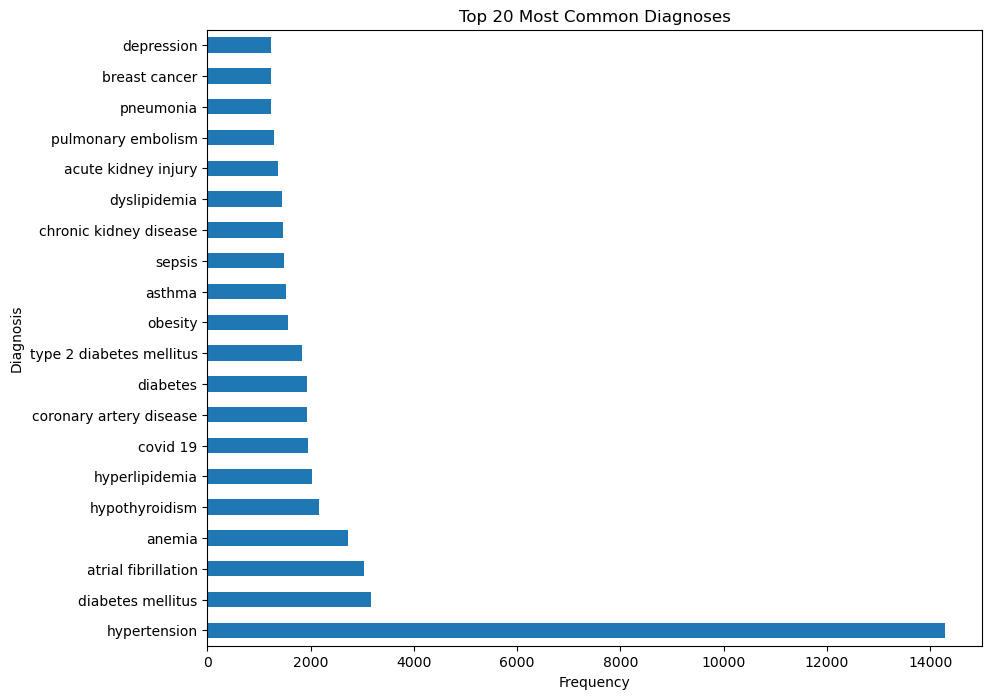

In [6]:
diagnosis_counts[:20].plot(kind='barh', figsize=(10, 8))
plt.title("Top 20 Most Common Diagnoses")
plt.xlabel("Frequency")
plt.ylabel("Diagnosis")
plt.show()

In [1]:
#diagnosis_data.keys()


## Analysis of Categories

In [1]:
import spacy
from scispacy.linking import EntityLinker

Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [ ]:
# Load the model and add the linker
nlp = spacy.load("en_core_sci_lg")
nlp.add_pipe("scispacy_linker", config={"resolve_abbreviations": True, "linker_name": "umls"})
linker = nlp.get_pipe("scispacy_linker")

/home/snoroozi/anaconda3/envs/t2s2/lib/python3.9/site-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]
/home/snoroozi/anaconda3/envs/t2s2/lib/python3.9/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/snoroozi/anaconda3/envs/t2s2/lib/python3.9/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_per

In [ ]:
# Function to map one diagnosis string to UMLS concepts
def link_diagnosis_text_as_dict(text, threshold=0.8, top_k=3):
    doc = nlp(text)
    linked_results = {}

    for ent in doc.ents:
        kb_ents = ent._.kb_ents
        if not kb_ents:
            continue

        # Filter by threshold, or fallback to top_k
        filtered = [(cui, score) for cui, score in kb_ents if score >= threshold]
        if not filtered:
            filtered = kb_ents[:top_k]

        linked_concepts = [
            {
                "cui": cui,
                "name": linker.kb.cui_to_entity[cui].canonical_name,
                "score": round(score, 4)
            }
            for cui, score in filtered
        ]

        linked_results[ent.text] = linked_concepts

    return linked_results

In [12]:
# Apply linking to your full diagnosis_data dict
linked_diagnosis_data = {}

for pmc_id, diagnoses in tqdm(diagnosis_data.items(), desc="Linking diagnoses", unit="file"):
    diag_links = {}
    for diag in diagnoses:
        links = link_diagnosis_text_as_dict(diag)
        diag_links.update(links)
    linked_diagnosis_data[pmc_id] = diag_links


Linking diagnoses: 100%|██████████| 124699/124699 [51:56<00:00, 40.01file/s]  


In [3]:
#linked_diagnosis_data.keys()

In [15]:
import pickle

with open("full_linked_diagnosis_data.pkl", "wb") as f:
    pickle.dump(linked_diagnosis_data, f)

In [1]:
linked_diagnosis_data[list(linked_diagnosis_data.keys())[0]]

NameError: name 'linked_diagnosis_data' is not defined